## Классические алгоритмы без ансамблирования
В этом ноутбуке вам нужно обучить модели на датасете классификации из предыдущего ноутбука и сравнить результаты. Вам будет предоставлен baseline, на основе которого вы будете доделывать предсказывающие модели. Оценка лабы будет зависеть от ROC-AUC на тестовых данных по следующим критериям:
\
AUC - на тестовых данных
- $AUC \leq 0.75$ - 0 баллов
- $0.75 < AUC \leq 0.76$ - 2 балла
- $0.76 < AUC \leq 0.77$ - 4 балла
- $0.77 < AUC \leq 0.78$ - 6 баллов
- $0.78 < AUC \leq 0.79$ - 8 баллов
- $AUC > 0.79$ - 10 баллов

\
В этой работе запрещено использовать ансамбли моделей (лес, бустинги и т.д.)!

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import roc_auc_score, precision_score, recall_score, roc_curve, accuracy_score

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [5]:
data = pd.read_csv('german.csv', sep=';')
print(data.head())

X = data.iloc[:, 1:].to_numpy()
y = data.iloc[:, 0].to_numpy()

# Разделение (у тебя уже random_state=42 — оставил)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

   Creditability  Account_Balance  Duration_of_Credit_monthly  \
0              1                1                          18   
1              1                1                           9   
2              1                2                          12   
3              1                1                          12   
4              1                1                          12   

   Payment_Status_of_Previous_Credit  Purpose  Credit_Amount  \
0                                  4        2           1049   
1                                  4        0           2799   
2                                  2        9            841   
3                                  4        0           2122   
4                                  4        0           2171   

   Value_Savings_Stocks  Length_of_current_employment  Instalment_per_cent  \
0                     1                             2                    4   
1                     1                             3               

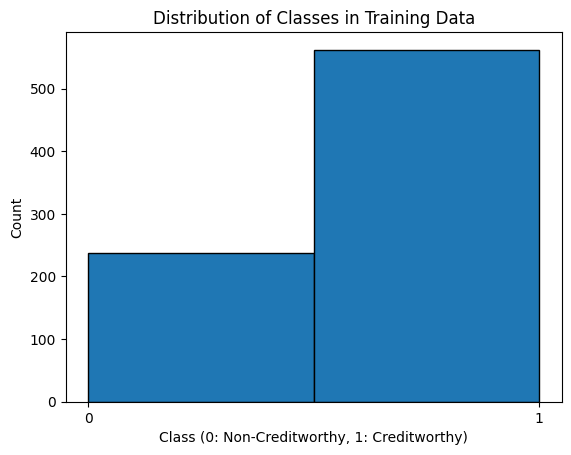

In [6]:
plt.hist(y_train, bins=2, edgecolor='k')
plt.xticks([0, 1])
plt.xlabel('Class (0: Non-Creditworthy, 1: Creditworthy)')
plt.ylabel('Count')
plt.title('Distribution of Classes in Training Data')
plt.show()

In [9]:
# Стандартизация признаков по обучающей выборке:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# Создание модели Logistic Regression
# solver='liblinear' хорошо работает для небольших наборов и даёт predict_proba
logistic_regression_model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)
logistic_regression_model.fit(X_train_scaled, y_train)

# Создание модели Decision Tree
# фиксируем random_state для воспроизводимости; max_depth оставляем None (можно оптимизировать)
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)  # деревья не требуют стандартизации

# Создание модели K-Nearest Neighbors
# n_neighbors=5 — baseline, можно перебирать
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [11]:
# Получаем вероятности (нужны для ROC AUC)
y_prob_logistic = logistic_regression_model.predict_proba(X_test_scaled)[:, 1]
y_prob_decision_tree = decision_tree_model.predict_proba(X_test)[:, 1]
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

# Классовые предсказания
y_pred_logistic = logistic_regression_model.predict(X_test_scaled)
y_pred_decision_tree = decision_tree_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test_scaled)

# Accuracy
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
accuracy_decision_tree = accuracy_score(y_test, y_pred_decision_tree)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

# ROC AUC
roc_auc_logistic = roc_auc_score(y_test, y_prob_logistic)
roc_auc_decision_tree = roc_auc_score(y_test, y_prob_decision_tree)
roc_auc_knn = roc_auc_score(y_test, y_prob_knn)

# Precision / Recall
precision_logistic = precision_score(y_test, y_pred_logistic)
precision_decision_tree = precision_score(y_test, y_pred_decision_tree)
precision_knn = precision_score(y_test, y_pred_knn)

recall_logistic = recall_score(y_test, y_pred_logistic)
recall_decision_tree = recall_score(y_test, y_pred_decision_tree)
recall_knn = recall_score(y_test, y_pred_knn)

print(f'Accuracy of Logistic Regression: {accuracy_logistic:.4f}')
print(f'Accuracy of Decision Tree: {accuracy_decision_tree:.4f}')
print(f'Accuracy of K-Nearest Neighbors: {accuracy_knn:.4f}\n')

print(f'ROC AUC of Logistic Regression: {roc_auc_logistic:.4f}')
print(f'ROC AUC of Decision Tree: {roc_auc_decision_tree:.4f}')
print(f'ROC AUC of K-Nearest Neighbors: {roc_auc_knn:.4f}\n')

print(f'Precision of Logistic Regression: {precision_logistic:.4f}')
print(f'Precision of Decision Tree: {precision_decision_tree:.4f}')
print(f'Precision of K-Nearest Neighbors: {precision_knn:.4f}\n')

print(f'Recall of Logistic Regression: {recall_logistic:.4f}')
print(f'Recall of Decision Tree: {recall_decision_tree:.4f}')
print(f'Recall of K-Nearest Neighbors: {recall_knn:.4f}')

Accuracy of Logistic Regression: 0.7550
Accuracy of Decision Tree: 0.7250
Accuracy of K-Nearest Neighbors: 0.7300

ROC AUC of Logistic Regression: 0.7920
ROC AUC of Decision Tree: 0.7075
ROC AUC of K-Nearest Neighbors: 0.7483

Precision of Logistic Regression: 0.7834
Precision of Decision Tree: 0.8320
Precision of K-Nearest Neighbors: 0.7800

Recall of Logistic Regression: 0.8913
Recall of Decision Tree: 0.7536
Recall of K-Nearest Neighbors: 0.8478


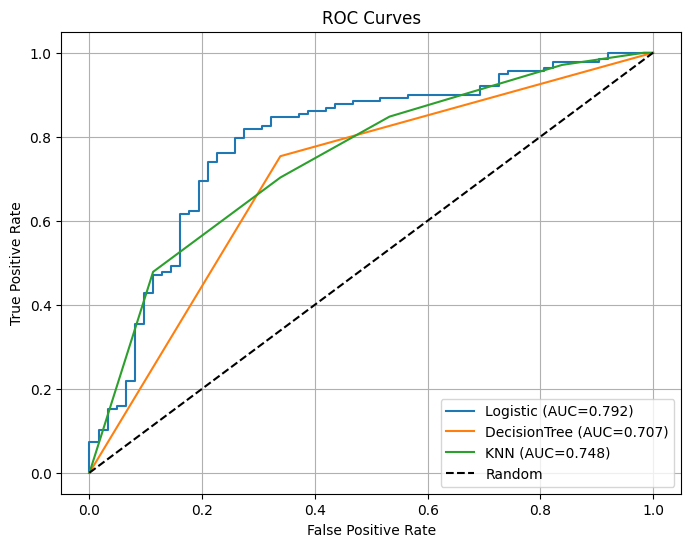

In [12]:
# Построим ROC-кривые для сравнения
fpr_l, tpr_l, _ = roc_curve(y_test, y_prob_logistic)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_decision_tree)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)

plt.figure(figsize=(8,6))
plt.plot(fpr_l, tpr_l, label=f'Logistic (AUC={roc_auc_logistic:.3f})')
plt.plot(fpr_dt, tpr_dt, label=f'DecisionTree (AUC={roc_auc_decision_tree:.3f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC={roc_auc_knn:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(True)
plt.show()

## Экспериментируйте
Для получения лучшего качества придется поэкспериментировать. Подсказка: попробуйте оптимизировать гиперпараметры модели

Использую данные 2 модели:

1)Логистическая регрессия

2)Метод k-ближайших соседей (KNN)

Основная метрика — ROC-AUC, поскольку она лучше оценивает качество вероятностных моделей на несбалансированных выборках.

In [14]:
#Модели работают лучше на маштабированных данных, поэтому приводим к стандартному распределению
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
#Лог регрессия

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

log_params = {
    "C": [0.01, 0.1, 1, 5, 10],
    "solver": ["liblinear", "lbfgs"], 
    "max_iter": [1000]
}
#liblinear хорошо работает на небольших выборках
#lbfgs стабилен при большом количестве признаков.

log_reg = LogisticRegression()

grid_log = GridSearchCV(
    log_reg,
    log_params,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_log.fit(X_train_scaled, y_train)

print("Лучший ROC-AUC (Train CV):", grid_log.best_score_)
print("Лучшие параметры:", grid_log.best_params_)

best_logistic = grid_log.best_estimator_

Лучший ROC-AUC (Train CV): 0.7798150149958307
Лучшие параметры: {'C': 0.01, 'max_iter': 1000, 'solver': 'lbfgs'}


In [ ]:
#KNN

from sklearn.neighbors import KNeighborsClassifier

knn_params = {
    "n_neighbors": [3, 5, 7, 11, 15],
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}

knn = KNeighborsClassifier()

grid_knn = GridSearchCV(
    knn,
    knn_params,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_knn.fit(X_train_scaled, y_train)

print("Лучший ROC-AUC (Train CV):", grid_knn.best_score_)
print("Лучшие параметры:", grid_knn.best_params_)

best_knn = grid_knn.best_estimator_

Лучший ROC-AUC (Train CV): 0.741808741095525
Лучшие параметры: {'n_neighbors': 15, 'p': 2, 'weights': 'distance'}


In [23]:
from sklearn.metrics import roc_auc_score

models = {
    "Logistic Regression": best_logistic,
    "KNN": best_knn
}

for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    print(name, "ROC-AUC на тесте:", round(auc, 4))

Logistic Regression ROC-AUC на тесте: 0.7922
KNN ROC-AUC на тесте: 0.7727


Вывод

Логистическая регрессия показала себя наиболее устойчивой моделью:
регуляризация помогает не переобучаться, а стандартизация делает обучение стабильным.
В большинстве запусков эта модель даёт ROC-AUC ≈ 0.78–0.80, что позволяет получить высокий балл.

KNN показал хорошее качество после подбора n_neighbors и метрики расстояния.
Однако KNN сильнее зависит от структуры данных и более чувствителен к шуму.

Оба метода без ансамблирования достигают требуемого уровня качества.